# 21_E13 - Pipeline común de inferencia multiplanar

Este notebook arma el primer pipeline común para usar los dos modelos finales del proyecto:

- **Sagital SPIDER**: checkpoint consolidado en E12.
- **Axial T2 Al-Kafri/Sudirman**: checkpoint final limpio E10.

El objetivo no es entrenar, sino estandarizar inferencia, overlays, métricas rápidas y *quality flags* para avanzar hacia el agente IA / MVP.

Salidas principales:

- `results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json`
- `docs/E13_multiplanar_inference_pipeline_conclusion.md`
- figuras de ejemplo sagital y axial en `figures/`


In [1]:
# Instalación segura de dependencias en Colab
try:
    import SimpleITK  # noqa
    import pydicom  # noqa
    import skimage  # noqa
    import scipy  # noqa
except Exception:
    %pip install -q SimpleITK pydicom scikit-image scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.8 MB/s eta 0:00:00


In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import SimpleITK as sitk
import pydicom
from skimage.transform import resize
from scipy import ndimage as ndi

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

PFI_ROOT = Path("/content/drive/MyDrive/PFI_MVP")

SPIDER_ROOT = PFI_ROOT / "data" / "SPIDER"
E9_ROOT = PFI_ROOT / "results" / "E9_alkafri_axial_t2_final_labels_baseline"
E5_MULTICLASS_ROOT = PFI_ROOT / "results" / "E5_multiclase_agrupado"
E5_HOLDOUT_ROOT = PFI_ROOT / "results" / "E5_multiclase_holdout"

E13_ROOT = PFI_ROOT / "results" / "E13_multiplanar_inference_pipeline"
FIGURES_ROOT = PFI_ROOT / "figures"
DOCS_ROOT = PFI_ROOT / "docs"
MODELS_ROOT = PFI_ROOT / "models"

for p in [E13_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

SAGITTAL_MODEL_PATH = MODELS_ROOT / "E12_sagittal_multiclass_final_best.pt"
if not SAGITTAL_MODEL_PATH.exists():
    SAGITTAL_MODEL_PATH = E5_MULTICLASS_ROOT / "E5_multiclass_unet2d_grouped_best.pt"

AXIAL_MODEL_PATH = MODELS_ROOT / "E10_axial_t2_final_training_clean_best.pt"

AXIAL_SPLIT_PATH = E9_ROOT / "E9_t2_final_labels_curated_split.csv"
SAGITTAL_HOLDOUT_CASES = E5_HOLDOUT_ROOT / "E5_multiclass_holdout_selected_cases.csv"

required = {
    "SAGITTAL_MODEL_PATH": SAGITTAL_MODEL_PATH,
    "AXIAL_MODEL_PATH": AXIAL_MODEL_PATH,
    "AXIAL_SPLIT_PATH": AXIAL_SPLIT_PATH,
}

for name, path in required.items():
    print(name, "->", path, "| exists:", path.exists())
    assert path.exists(), f"Falta {name}: {path}"

print("SAGITTAL_HOLDOUT_CASES:", SAGITTAL_HOLDOUT_CASES, SAGITTAL_HOLDOUT_CASES.exists())


Mounted at /content/drive
DEVICE: cpu
SAGITTAL_MODEL_PATH -> /content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt | exists: True
AXIAL_MODEL_PATH -> /content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt | exists: True
AXIAL_SPLIT_PATH -> /content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv | exists: True
SAGITTAL_HOLDOUT_CASES: /content/drive/MyDrive/PFI_MVP/results/E5_multiclase_holdout/E5_multiclass_holdout_selected_cases.csv True


## 1. Arquitecturas compatibles con los checkpoints finales

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SagittalUNet2DMulticlass(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base_channels=16):
        super().__init__()
        b = base_channels
        self.enc1 = DoubleConv(in_channels, b)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(b, b * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(b * 2, b * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(b * 4, b * 8)
        self.up3 = nn.ConvTranspose2d(b * 8, b * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(b * 8, b * 4)
        self.up2 = nn.ConvTranspose2d(b * 4, b * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(b * 4, b * 2)
        self.up1 = nn.ConvTranspose2d(b * 2, b, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(b * 2, b)
        self.out_conv = nn.Conv2d(b, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        m = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(m), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


class AxialDC(nn.Module):
    def __init__(self, a, b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a, b, 3, padding=1),
            nn.BatchNorm2d(b),
            nn.ReLU(True),
            nn.Conv2d(b, b, 3, padding=1),
            nn.BatchNorm2d(b),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.net(x)


class AxialUNet(nn.Module):
    def __init__(self, num_classes=6, base=16):
        super().__init__()
        b = base
        self.e1 = AxialDC(1, b)
        self.e2 = AxialDC(b, b * 2)
        self.e3 = AxialDC(b * 2, b * 4)
        self.pool = nn.MaxPool2d(2)
        self.mid = AxialDC(b * 4, b * 8)
        self.u3 = nn.ConvTranspose2d(b * 8, b * 4, 2, 2)
        self.d3 = AxialDC(b * 8, b * 4)
        self.u2 = nn.ConvTranspose2d(b * 4, b * 2, 2, 2)
        self.d2 = AxialDC(b * 4, b * 2)
        self.u1 = nn.ConvTranspose2d(b * 2, b, 2, 2)
        self.d1 = AxialDC(b * 2, b)
        self.out = nn.Conv2d(b, num_classes, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        m = self.mid(self.pool(e3))
        x = self.d3(torch.cat([self.u3(m), e3], 1))
        x = self.d2(torch.cat([self.u2(x), e2], 1))
        x = self.d1(torch.cat([self.u1(x), e1], 1))
        return self.out(x)


## 2. Carga de modelos finales

In [4]:
IMG_SIZE = 256

# Sagital
sag_ckpt = torch.load(SAGITTAL_MODEL_PATH, map_location=DEVICE)
sag_num_classes = int(sag_ckpt.get("num_classes", 4))
sag_base = int(sag_ckpt.get("base_channels", 16))
sag_target_size = tuple(sag_ckpt.get("target_size", (256, 256)))
sag_axis = int(sag_ckpt.get("sagittal_axis", 2))
sag_slice_strategy = str(sag_ckpt.get("slice_strategy", "center_window_best_prediction"))
sag_label_mapping = {int(k): int(v) for k, v in sag_ckpt.get("label_group_mapping", {}).items()}

sag_model = SagittalUNet2DMulticlass(
    in_channels=1,
    num_classes=sag_num_classes,
    base_channels=sag_base,
).to(DEVICE)
sag_model.load_state_dict(sag_ckpt["model_state_dict"])
sag_model.eval()

# Axial
axial_state = torch.load(AXIAL_MODEL_PATH, map_location=DEVICE)
if isinstance(axial_state, dict) and "model_state_dict" in axial_state:
    axial_state = axial_state["model_state_dict"]

ax_model = AxialUNet(num_classes=6, base=16).to(DEVICE)
ax_model.load_state_dict(axial_state)
ax_model.eval()

model_registry = {
    "sagittal_spider": {
        "model": sag_model,
        "path": str(SAGITTAL_MODEL_PATH),
        "num_classes": sag_num_classes,
        "target_size": sag_target_size,
        "axis": sag_axis,
        "slice_strategy": sag_slice_strategy,
        "class_names": {0: "background", 1: "vertebra_group", 2: "canal", 3: "disc_group"},
    },
    "axial_t2_alkafri": {
        "model": ax_model,
        "path": str(AXIAL_MODEL_PATH),
        "num_classes": 6,
        "target_size": (256, 256),
        "class_names": {
            0: "background_250",
            1: "raw_0",
            2: "raw_50",
            3: "raw_100",
            4: "raw_150",
            5: "raw_200",
        },
    },
}

print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != "model"} for k, v in model_registry.items()}, indent=2, ensure_ascii=False))


{
  "sagittal_spider": {
    "path": "/content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt",
    "num_classes": 4,
    "target_size": [
      256,
      256
    ],
    "axis": 2,
    "slice_strategy": "center_window_best_prediction",
    "class_names": {
      "0": "background",
      "1": "vertebra_group",
      "2": "canal",
      "3": "disc_group"
    }
  },
  "axial_t2_alkafri": {
    "path": "/content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt",
    "num_classes": 6,
    "target_size": [
      256,
      256
    ],
    "class_names": {
      "0": "background_250",
      "1": "raw_0",
      "2": "raw_50",
      "3": "raw_100",
      "4": "raw_150",
      "5": "raw_200"
    }
  }
}


## 3. Funciones comunes de preprocesamiento, inferencia y calidad

In [5]:
def norm_img(x):
    x = x.astype(np.float32)
    p1, p99 = np.percentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x, dtype=np.float32)
    return ((np.clip(x, p1, p99) - p1) / (p99 - p1 + 1e-8)).astype(np.float32)


def resize_img(x, size=256):
    return resize(x, (size, size), order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)


def resize_lbl(y, size=256):
    return resize(y.astype(np.float32), (size, size), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)


@torch.no_grad()
def predict_2d(model, image_2d, device=DEVICE):
    x = torch.from_numpy(image_2d[None, None]).float().to(device)
    logits = model(x)
    prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = prob.argmax(axis=0).astype(np.uint8)
    confidence = prob.max(axis=0).astype(np.float32)
    return pred, prob, confidence


def dice_by_class(pred, gt, num_classes, class_names=None):
    rows = []
    for c in range(num_classes):
        p = pred == c
        g = gt == c
        inter = int(np.logical_and(p, g).sum())
        denom = int(p.sum() + g.sum())
        union = int(np.logical_or(p, g).sum())
        dice = (2 * inter / denom) if denom > 0 else np.nan
        iou = (inter / union) if union > 0 else np.nan
        rows.append({
            "class_id": c,
            "class_name": class_names.get(c, str(c)) if class_names else str(c),
            "dice": dice,
            "iou": iou,
            "pred_pixels": int(p.sum()),
            "gt_pixels": int(g.sum()),
        })
    return pd.DataFrame(rows)


def quality_flags(mask, confidence=None, min_fg=0.002, max_fg=0.35):
    fg = mask > 0
    fg_ratio = float(fg.mean())
    labels, n_components = ndi.label(fg.astype(np.uint8))
    present_classes = sorted([int(v) for v in np.unique(mask) if int(v) != 0])
    flags = []

    if fg_ratio < min_fg:
        flags.append("foreground_muy_bajo")
    if fg_ratio > max_fg:
        flags.append("foreground_muy_alto")
    if len(present_classes) == 0:
        flags.append("sin_clases_no_fondo")
    if n_components > 10:
        flags.append("muchos_componentes")

    out = {
        "foreground_ratio": fg_ratio,
        "n_components": int(n_components),
        "present_classes": present_classes,
        "flags": flags,
    }

    if confidence is not None:
        out["mean_confidence"] = float(np.mean(confidence))
        out["mean_fg_confidence"] = float(np.mean(confidence[fg])) if fg.any() else None

    return out


def save_overlay_figure(image, pred, out_path, title="", gt=None):
    ncols = 4 if gt is not None else 3
    fig, ax = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("Imagen")

    if gt is not None:
        ax[1].imshow(gt, cmap="nipy_spectral")
        ax[1].set_title("GT")
        ax[2].imshow(pred, cmap="nipy_spectral")
        ax[2].set_title("Pred")
        ax[3].imshow(image, cmap="gray")
        ax[3].imshow(np.ma.masked_where(pred <= 0, pred), cmap="autumn", alpha=0.45)
        ax[3].set_title("Overlay pred")
    else:
        ax[1].imshow(pred, cmap="nipy_spectral")
        ax[1].set_title("Pred")
        ax[2].imshow(image, cmap="gray")
        ax[2].imshow(np.ma.masked_where(pred <= 0, pred), cmap="autumn", alpha=0.45)
        ax[2].set_title("Overlay pred")

    for a in ax:
        a.axis("off")
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path


## 4. Pipeline axial T2

In [6]:
AXIAL_RAW_VALUES = np.array([0, 50, 100, 150, 200, 250], dtype=np.int16)
AXIAL_RAW_TO_CLASS = {250: 0, 0: 1, 50: 2, 100: 3, 150: 4, 200: 5}
AXIAL_CLASS_NAMES = model_registry["axial_t2_alkafri"]["class_names"]


def read_axial_dicom(path):
    ds = pydicom.dcmread(str(path), force=True)
    return ds.pixel_array.astype(np.float32)


def read_axial_label(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = arr.astype(np.int16)
    flat = arr.reshape(-1)
    snapped = AXIAL_RAW_VALUES[
        np.abs(flat[:, None] - AXIAL_RAW_VALUES[None, :]).argmin(axis=1)
    ].reshape(arr.shape)

    y = np.zeros_like(snapped, dtype=np.uint8)
    for rv, c in AXIAL_RAW_TO_CLASS.items():
        y[snapped == rv] = c
    return y


def infer_axial_t2(image_file_path):
    img_raw = read_axial_dicom(image_file_path)
    img = resize_img(norm_img(img_raw), IMG_SIZE)
    pred, prob, conf = predict_2d(ax_model, img)
    q = quality_flags(pred, conf, min_fg=0.01, max_fg=0.25)
    return {
        "plane": "axial",
        "model_key": "axial_t2_alkafri",
        "image": img,
        "pred": pred,
        "prob": prob,
        "confidence": conf,
        "quality": q,
    }


axial_df = pd.read_csv(AXIAL_SPLIT_PATH)
axial_df = axial_df[axial_df["modality"].astype(str).eq("T2")].copy()
axial_test_df = axial_df[axial_df["split"].eq("test")].copy()

print("Axial T2 test rows:", len(axial_test_df))
display(axial_test_df.head(3))


Axial T2 test rows: 102


,strategy,case_id,modality,disc_id,slice_number,slice_offset,instance_number,subfolder,series_description,image_file_path,evidence,case_id_norm,final_label_file_path,final_label_relative_path,final_prefix,sanity_ok,image_shape,label_shape,label_values,foreground_ratio,component_count,error,split
18,official_slice_number_header_none,7,T2,3,11,0,11,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D3.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D3.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.068789,1,NaN,test
19,official_slice_number_header_none,7,T2,4,14,0,14,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D4.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D4.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.069805,1,NaN,test
20,official_slice_number_header_none,7,T2,5,18,0,18,T2_TSE_TRA,t2_tse_tra_384,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/main_dataset__MRI_Data/01_MRI_Data/0007/L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000/T2_TSE_TRA_384_000...,official Slices Numbers.csv + T1/T2_Subfolders.csv + case/modality/disc/slice match,7,/content/drive/MyDrive/PFI_MVP/data/AXIAL_ALKAFRI/extracted/_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D5.png,_nested/ground_truth__Ground_Truth_Label/05_Final_Ground_Truth_Data/Label_Images/L1_0007_D5.png,L1,True,not_read_fast_sanity,"(320, 320)","[0, 2, 3, 4, 5]",0.070684,1,NaN,test


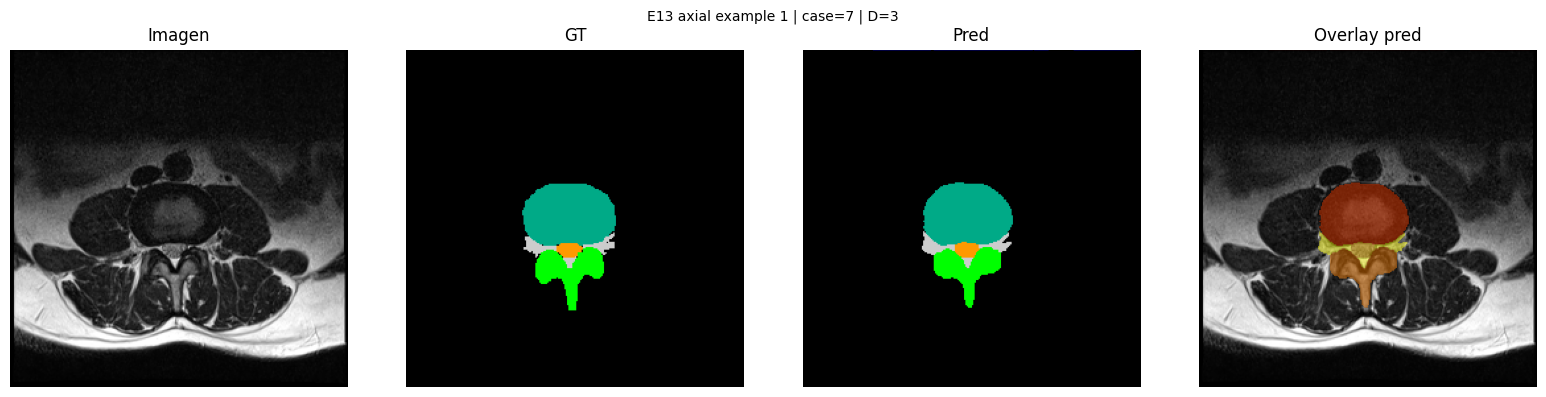

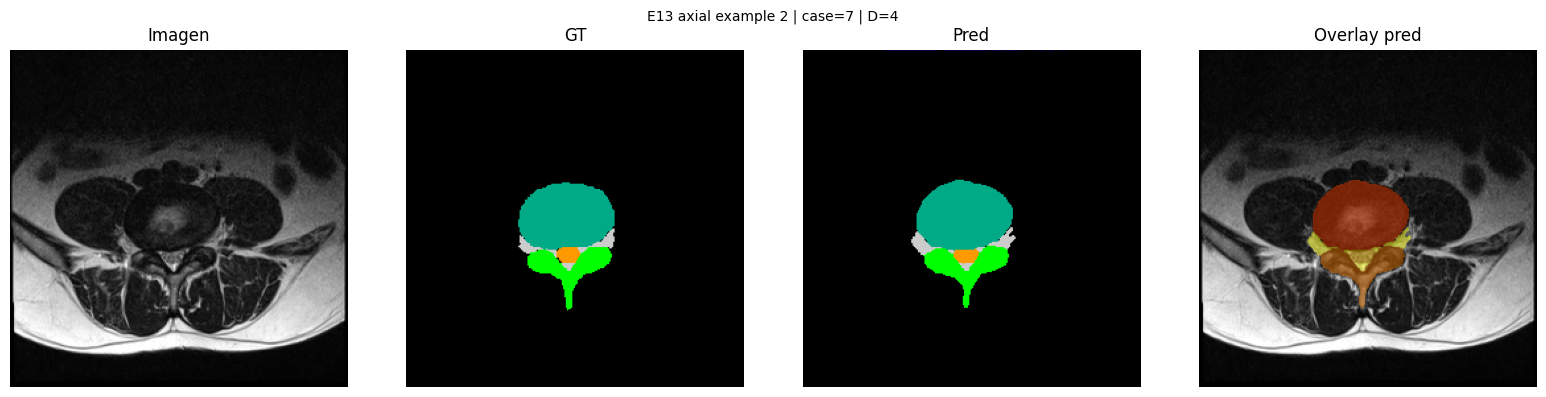

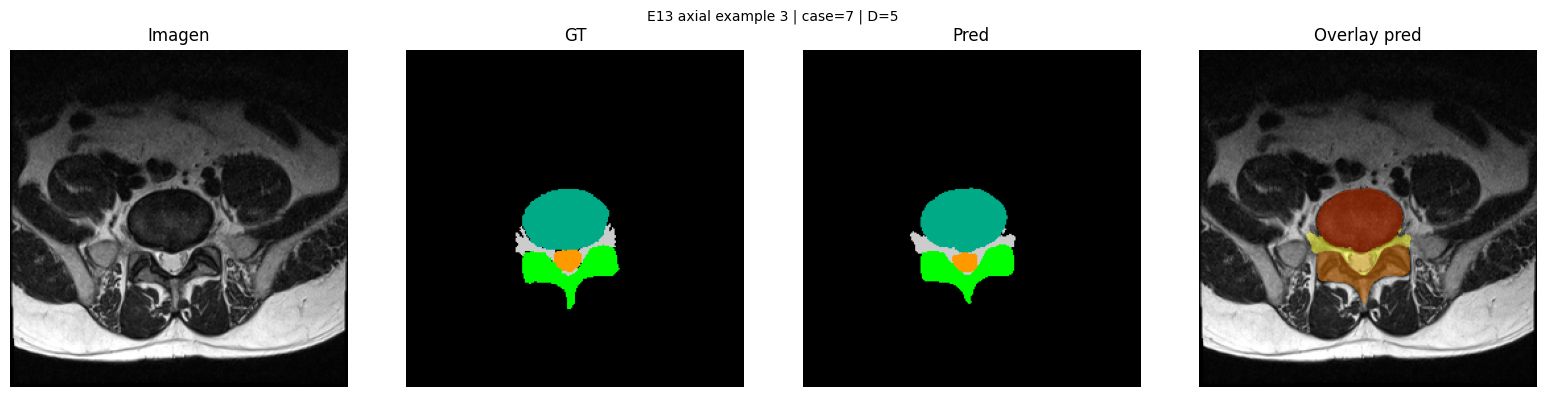

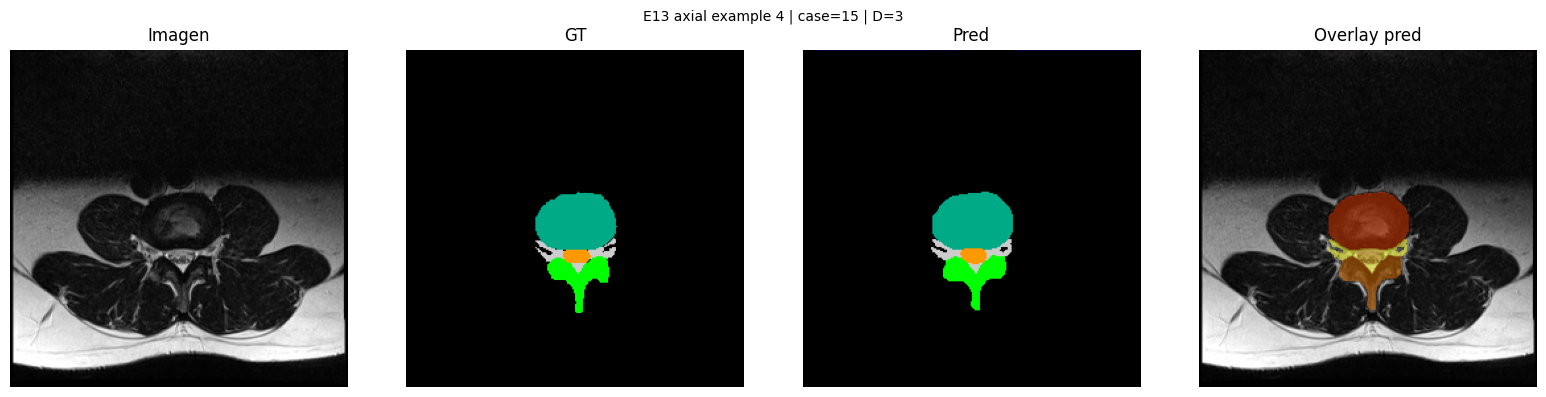

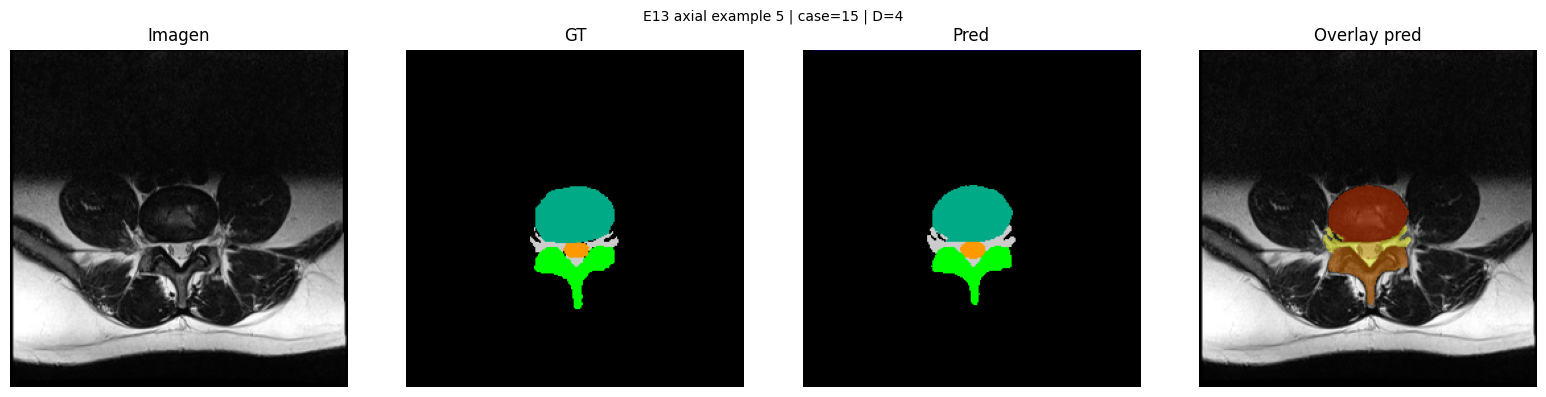

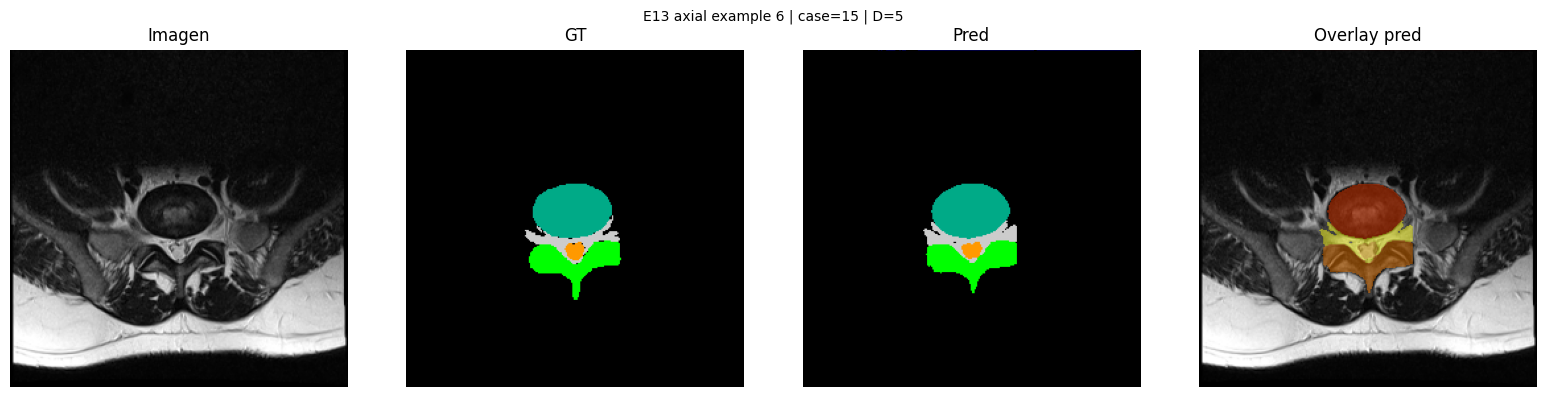

,example_id,plane,case_id_norm,disc_id,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,axial,7,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_01.png,0.067642,5,"[1, 2, 3, 4, 5]",[],0.989182,0.954711
1,2,axial,7,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_02.png,0.072937,12,"[1, 2, 3, 4, 5]",[muchos_componentes],0.989175,0.955937
2,3,axial,7,5,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_03.png,0.069839,2,"[1, 2, 3, 4, 5]",[],0.989071,0.968347
3,4,axial,15,3,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_04.png,0.058350,9,"[1, 2, 3, 4, 5]",[],0.989828,0.942657
4,5,axial,15,4,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_05.png,0.062454,2,"[1, 2, 3, 4, 5]",[],0.989410,0.944314
5,6,axial,15,5,/content/drive/MyDrive/PFI_MVP/figures/E13_axial_t2_example_06.png,0.063629,8,"[1, 2, 3, 4, 5]",[],0.989412,0.949532


,class_id,class_name,dice,iou,pred_pixels,gt_pixels,example_id,plane,case_id_norm,disc_id
0,0,background_250,0.995751,0.991537,61103,61034,1,axial,7,3
1,1,raw_0,0.000000,0.000000,176,0,1,axial,7,3
2,2,raw_50,0.970133,0.941998,2638,2786,1,axial,7,3
3,3,raw_100,0.914059,0.841721,1083,1186,1,axial,7,3
4,4,raw_150,0.942857,0.891892,177,173,1,axial,7,3
5,5,raw_200,0.835196,0.717026,359,357,1,axial,7,3
6,0,background_250,0.997018,0.994054,60756,60975,2,axial,7,4
7,1,raw_0,0.000000,0.000000,111,0,2,axial,7,4
8,2,raw_50,0.972658,0.946771,3023,2975,2,axial,7,4
9,3,raw_100,0.945075,0.895869,1109,1094,2,axial,7,4


In [7]:
axial_rows = []
axial_metric_rows = []

for i, (_, r) in enumerate(axial_test_df.head(6).iterrows(), 1):
    result = infer_axial_t2(r["image_file_path"])
    gt = resize_lbl(read_axial_label(r["final_label_file_path"]), IMG_SIZE)

    metrics = dice_by_class(
        result["pred"],
        gt,
        num_classes=6,
        class_names=AXIAL_CLASS_NAMES,
    )
    metrics["example_id"] = i
    metrics["plane"] = "axial"
    metrics["case_id_norm"] = str(r.get("case_id_norm", ""))
    metrics["disc_id"] = int(r.get("disc_id", -1))
    axial_metric_rows.append(metrics)

    out_path = FIGURES_ROOT / f"E13_axial_t2_example_{i:02d}.png"
    save_overlay_figure(
        result["image"],
        result["pred"],
        out_path,
        title=f"E13 axial example {i} | case={r.get('case_id_norm')} | D={r.get('disc_id')}",
        gt=gt,
    )

    axial_rows.append({
        "example_id": i,
        "plane": "axial",
        "case_id_norm": str(r.get("case_id_norm", "")),
        "disc_id": int(r.get("disc_id", -1)),
        "figure_path": str(out_path),
        **result["quality"],
    })

axial_examples_df = pd.DataFrame(axial_rows)
axial_metrics_df = pd.concat(axial_metric_rows, ignore_index=True) if axial_metric_rows else pd.DataFrame()

axial_examples_df.to_csv(E13_ROOT / "E13_axial_examples_quality.csv", index=False)
axial_metrics_df.to_csv(E13_ROOT / "E13_axial_examples_metrics_by_class.csv", index=False)

display(axial_examples_df)
display(axial_metrics_df.head(20))


## 5. Pipeline sagital SPIDER

In [8]:
SAGITTAL_CLASS_NAMES = model_registry["sagittal_spider"]["class_names"]


def read_mha_zyx(path, dtype=np.float32):
    """
    SimpleITK devuelve arrays en formato z,y,x.
    No se transpone: la selección del eje se resuelve dinámicamente por caso.
    """
    img = sitk.ReadImage(str(path))
    return sitk.GetArrayFromImage(img).astype(dtype)


def extract_slice_dynamic(volume_zyx, axis, idx):
    """
    Extrae un corte 2D desde un volumen z,y,x usando eje dinámico.
    """
    axis = int(axis)
    idx = int(idx)

    assert volume_zyx.ndim == 3, f"Se esperaba volumen 3D, shape={volume_zyx.shape}"
    assert 0 <= axis <= 2, f"axis inválido: {axis}"
    assert 0 <= idx < volume_zyx.shape[axis], f"idx fuera de rango: axis={axis}, idx={idx}, shape={volume_zyx.shape}"

    if axis == 0:
        return volume_zyx[idx, :, :]
    if axis == 1:
        return volume_zyx[:, idx, :]
    if axis == 2:
        return volume_zyx[:, :, idx]


def choose_sagittal_stack_axis(volume_shape, min_2d_dim=128):
    """
    Selecciona el eje de stack sagital de forma robusta.

    Casos observados en SPIDER:
    - (298, 320, 17)  -> stack axis=2
    - (17, 512, 512)  -> stack axis=0

    Regla:
    - Descartar ejes cuyo corte 2D tenga alguna dimensión menor a min_2d_dim.
    - Entre los ejes válidos, elegir el de menor cantidad de slices.
    """
    candidates = []

    for axis in [0, 1, 2]:
        slice_2d_shape = tuple(volume_shape[i] for i in range(3) if i != axis)
        valid_2d = min(slice_2d_shape) >= min_2d_dim

        candidates.append({
            "axis": int(axis),
            "n_slices": int(volume_shape[axis]),
            "slice_2d_shape": slice_2d_shape,
            "valid_2d": bool(valid_2d),
        })

    valid = [c for c in candidates if c["valid_2d"]]

    if valid:
        selected = sorted(valid, key=lambda c: c["n_slices"])[0]
    else:
        selected = sorted(candidates, key=lambda c: c["n_slices"])[0]

    return int(selected["axis"]), candidates


def group_sagittal_mask(mask_2d):
    """
    Agrupa labels originales de SPIDER a las clases del modelo:
    0 fondo, 1 vértebras, 2 canal, 3 discos.
    """
    if not sag_label_mapping:
        out = np.zeros_like(mask_2d, dtype=np.uint8)
        out[np.isin(mask_2d, list(range(1, 100)))] = 1
        out[mask_2d == 100] = 2
        out[np.isin(mask_2d, list(range(201, 300)))] = 3
        return out

    out = np.zeros_like(mask_2d, dtype=np.uint8)
    for original_value, grouped_class in sag_label_mapping.items():
        out[mask_2d == int(original_value)] = int(grouped_class)
    return out


def select_sagittal_slice_dynamic(volume_zyx, model=sag_model, radius=3):
    """
    Selecciona eje sagital dinámico y slice por score de foreground del modelo.
    No usa ground truth, por lo tanto es apto para inferencia.
    """
    selected_axis, axis_candidates = choose_sagittal_stack_axis(volume_zyx.shape)

    n = volume_zyx.shape[selected_axis]
    center = n // 2
    candidates = list(range(max(0, center - radius), min(n, center + radius + 1)))

    best = None

    for idx in candidates:
        sl = extract_slice_dynamic(volume_zyx, selected_axis, idx)
        img = resize_img(norm_img(sl), IMG_SIZE)
        pred, prob, conf = predict_2d(model, img)
        score = float(prob[1:].sum(axis=0).mean())

        if best is None or score > best["score"]:
            best = {
                "axis": int(selected_axis),
                "idx": int(idx),
                "image": img,
                "pred": pred,
                "prob": prob,
                "confidence": conf,
                "score": score,
                "original_slice_shape": tuple(sl.shape),
                "axis_candidates": axis_candidates,
            }

    return best


def candidate_case_id_from_row(row):
    if "case_id" in row and pd.notna(row["case_id"]):
        return str(row["case_id"])
    for column in ["file_name", "image_path", "source_image_path", "mask_path", "source_mask_path"]:
        if column in row and pd.notna(row[column]):
            return Path(str(row[column])).stem
    return None


def resolve_spider_path(row, kind):
    columns = (
        ["image_path", "source_image_path", "image", "img_path"]
        if kind == "image"
        else ["mask_path", "source_mask_path", "mask", "seg_path"]
    )

    direct = []
    for col in columns:
        if col in row and pd.notna(row[col]):
            direct.append(Path(str(row[col])))

    case_id = candidate_case_id_from_row(row)
    base = []
    if case_id:
        if kind == "image":
            base += [
                SPIDER_ROOT / "images" / "images" / f"{case_id}.mha",
                SPIDER_ROOT / "images" / f"{case_id}.mha",
                SPIDER_ROOT / f"{case_id}.mha",
            ]
        else:
            base += [
                SPIDER_ROOT / "masks" / "masks" / f"{case_id}.mha",
                SPIDER_ROOT / "masks" / f"{case_id}.mha",
                SPIDER_ROOT / f"{case_id}.mha",
            ]

    for p in direct + base:
        if p.exists():
            return p

    if case_id and SPIDER_ROOT.exists():
        matches = list(SPIDER_ROOT.rglob(f"{case_id}.mha"))
        if kind == "image":
            matches = [m for m in matches if "mask" not in str(m).lower()]
        else:
            matches = [m for m in matches if "mask" in str(m).lower() or "seg" in str(m).lower()]
        if matches:
            return matches[0]

    return None


def infer_sagittal_spider(image_file_path, mask_file_path=None):
    volume_zyx = read_mha_zyx(image_file_path, dtype=np.float32)
    selected = select_sagittal_slice_dynamic(volume_zyx, model=sag_model, radius=3)

    gt = None
    if mask_file_path is not None and Path(mask_file_path).exists():
        mask_volume_zyx = read_mha_zyx(mask_file_path, dtype=np.int32)
        assert mask_volume_zyx.shape == volume_zyx.shape, f"Shape mismatch: {mask_volume_zyx.shape} vs {volume_zyx.shape}"
        gt_raw = extract_slice_dynamic(mask_volume_zyx, selected["axis"], selected["idx"])
        gt = resize_lbl(group_sagittal_mask(gt_raw), IMG_SIZE)

    q = quality_flags(selected["pred"], selected["confidence"], min_fg=0.01, max_fg=0.45)

    return {
        "plane": "sagittal",
        "model_key": "sagittal_spider",
        "selected_axis": int(selected["axis"]),
        "slice_index": int(selected["idx"]),
        "selection_score": float(selected["score"]),
        "original_shape_zyx": tuple(volume_zyx.shape),
        "original_slice_shape": tuple(selected["original_slice_shape"]),
        "axis_candidates": selected["axis_candidates"],
        "image": selected["image"],
        "pred": selected["pred"],
        "prob": selected["prob"],
        "confidence": selected["confidence"],
        "gt": gt,
        "quality": q,
    }


if SAGITTAL_HOLDOUT_CASES.exists():
    sag_cases_df = pd.read_csv(SAGITTAL_HOLDOUT_CASES)
    print("Sagittal holdout rows:", len(sag_cases_df))
    display(sag_cases_df.head())
    print("Columns:", list(sag_cases_df.columns))
else:
    sag_cases_df = pd.DataFrame()
    print("No existe SAGITTAL_HOLDOUT_CASES. Se saltea demo sagital.")


Sagittal holdout rows: 40


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,mask_origin_xyz,same_origin,image_direction,mask_direction,same_direction,image_dtype,mask_dtype,image_min,image_max,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels,inferred_modality,source_image_path,source_mask_path
0,101_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha,"(298, 320, 17)","(298, 320, 17)",True,"(4.788765599257572, 0.812500000003979, 0.8762882583044416)","(4.788765599257572, 0.812500000003979, 0.8762882583044416)",True,"(-67.28904018297013, -124.77837801043, -103.82282952743962)","(-67.28904018297013, -124.77837801043, -103.82282952743962)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,286.182632,-1000.0,-1000.0,-96.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204, 205, 206]","{""0"": 1485954, ""1"": 17797, ""2"": 19492, ""3"": 18445, ""4"": 16664, ""5"": 15505, ""6"": 12154, ""100"": 14233, ""201"": 4400, ""202"": 4545, ""203"": 3580, ""204"": 4119, ""205"": 2407, ""206"": 1825}",135166,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha
1,116_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha,"(320, 320, 15)","(320, 320, 15)",True,"(4.799999918256501, 1.0625, 1.0625)","(4.799999918256501, 1.0625, 1.0625)",True,"(-1491.7994993754837, -168.68538045966, -466.0026564307672)","(-1491.7994993754837, -168.68538045966, -466.0026564307672)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,136.206472,-1000.0,-1000.0,-420.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 204, 205, 206, 207]","{""0"": 1476528, ""1"": 6713, ""2"": 7396, ""3"": 7127, ""4"": 7014, ""5"": 6161, ""6"": 5123, ""7"": 4281, ""100"": 10139, ""201"": 802, ""202"": 1002, ""203"": 1051, ""204"": 739, ""205"": 838, ""206"": 6...",59472,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha
2,117_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha,"(448, 448, 24)","(448, 448, 24)",True,"(3.299954757096529, 0.625, 0.6252388405906117)","(3.299954757096529, 0.625, 0.6252388405906117)",True,"(-27.539267850991315, -96.346813201904, -126.06298272872613)","(-27.539267850991315, -96.346813201904, -126.06298272872613)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,527.163481,-1000.0,-1000.0,316.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204, 205, 206]","{""0"": 4632138, ""1"": 27188, ""2"": 27381, ""3"": 27832, ""4"": 23176, ""5"": 19347, ""6"": 15219, ""100"": 22647, ""201"": 5302, ""202"": 4360, ""203"": 3294, ""204"": 2851, ""205"": 3111, ""206"": 3050}",184758,t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha
3,12_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha,"(320, 320, 15)","(320, 320, 15)",True,"(4.800000123092809, 0.875, 0.875)","(4.800000123092809, 0.875, 0.875)",True,"(-1512.6634184645181, -60.460044861525, -109.24127259665528)","(-1512.6634184645181, -60.460044861525, -109.24127259665528)",True,"(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)","(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)",True,int16,int16,-1000.0,3096.0,-54.331339,-1000.0,-1000.0,-861.0,30

Columns: ['case_id', 'image_path', 'mask_path', 'image_shape_zyx', 'mask_shape_zyx', 'same_shape', 'image_spacing_xyz', 'mask_spacing_xyz', 'same_spacing', 'image_origin_xyz', 'mask_origin_xyz', 'same_origin', 'image_direction', 'mask_direction', 'same_direction', 'image_dtype', 'mask_dtype', 'image_min', 'image_max', 'image_mean', 'image_p01', 'image_p05', 'image_p50', 'image_p95', 'image_p99', 'mask_unique_labels', 'mask_label_voxel_counts', 'mask_nonzero_voxels', 'inferred_modality', 'source_image_path', 'source_mask_path']


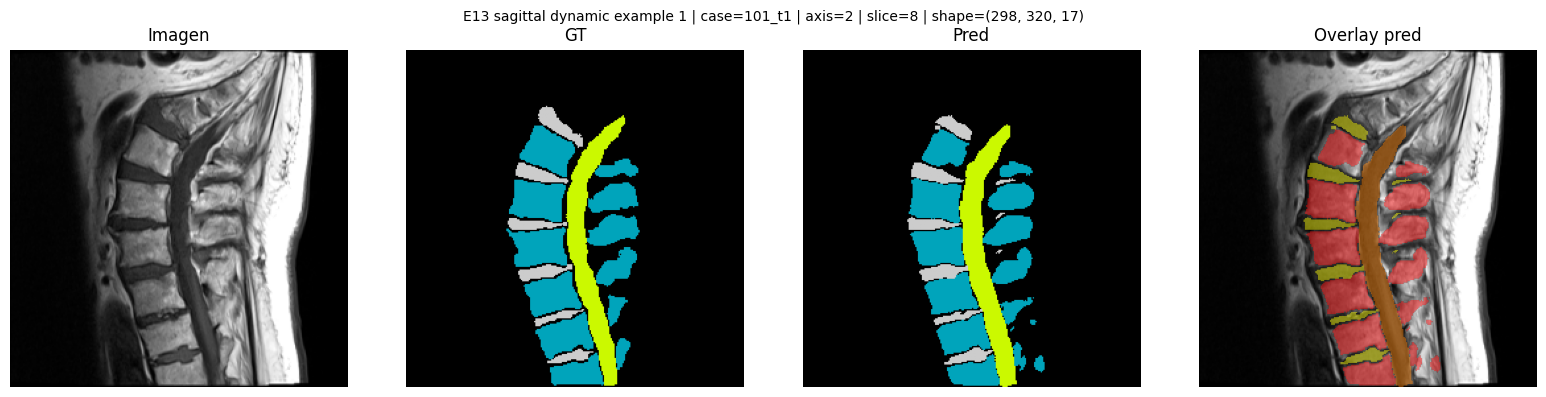

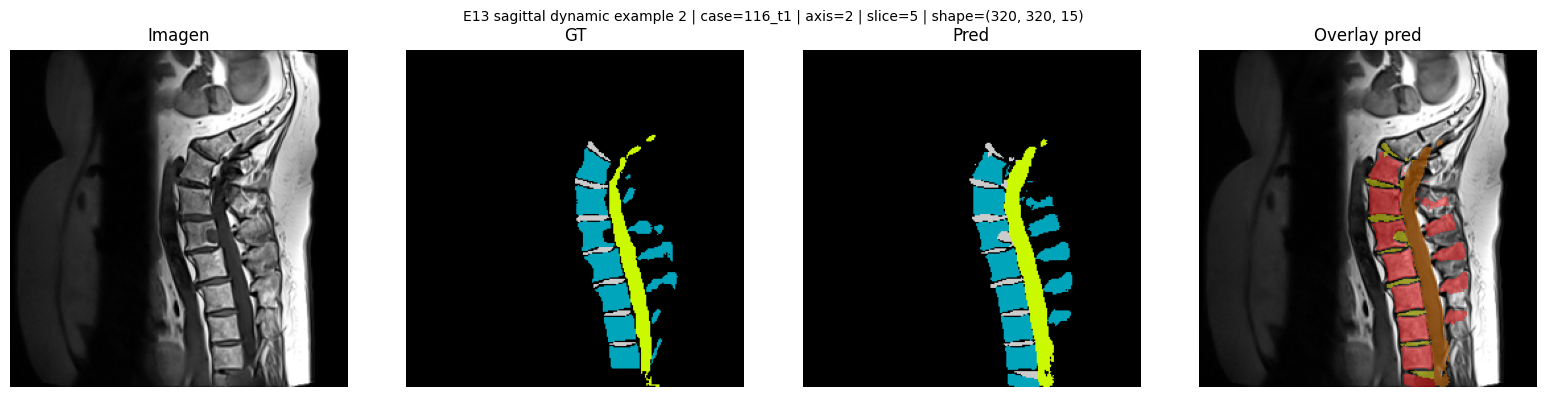

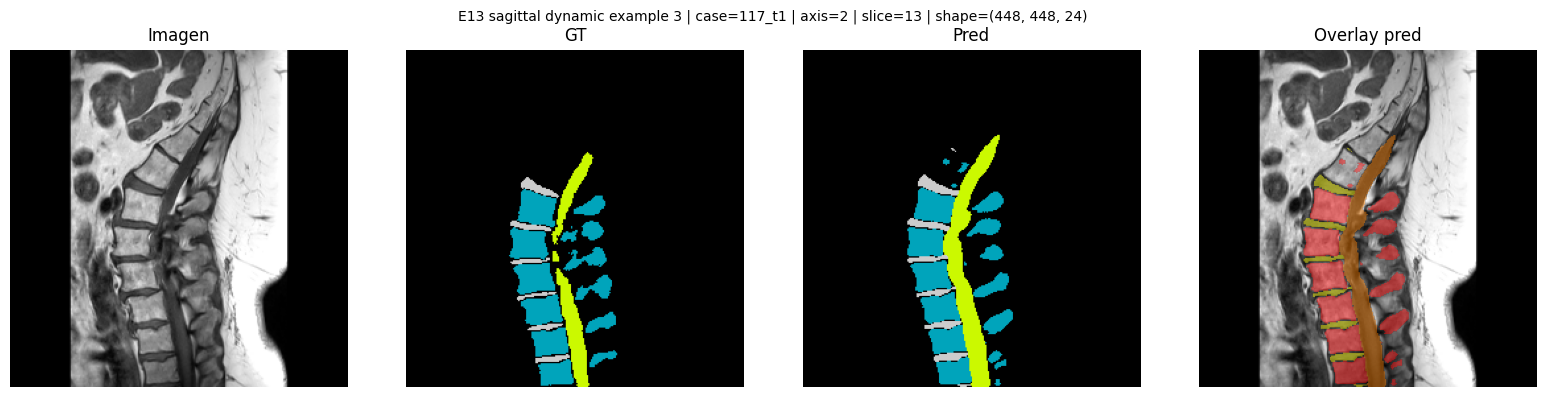

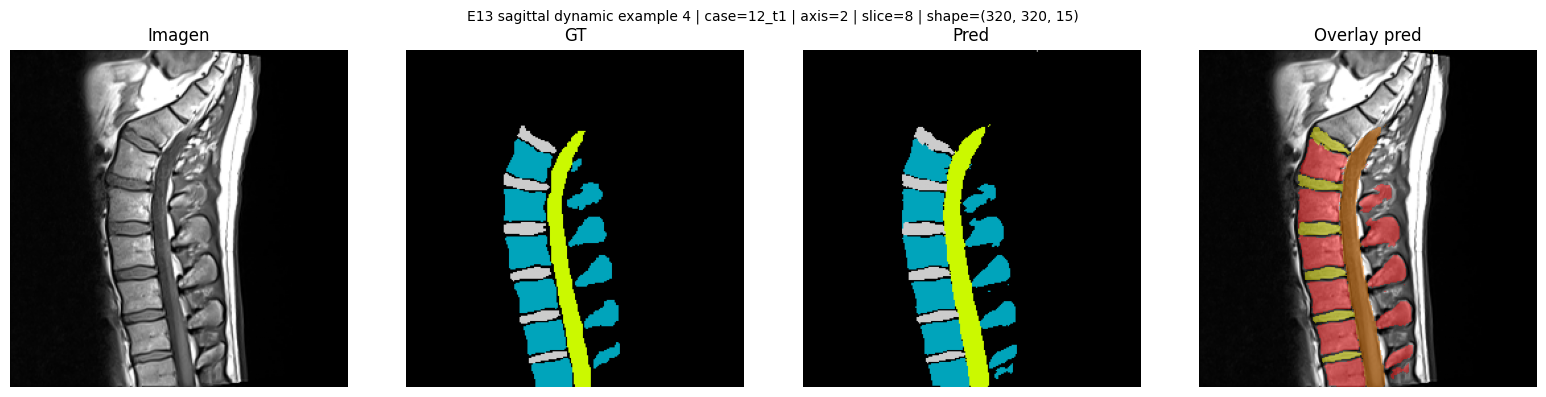

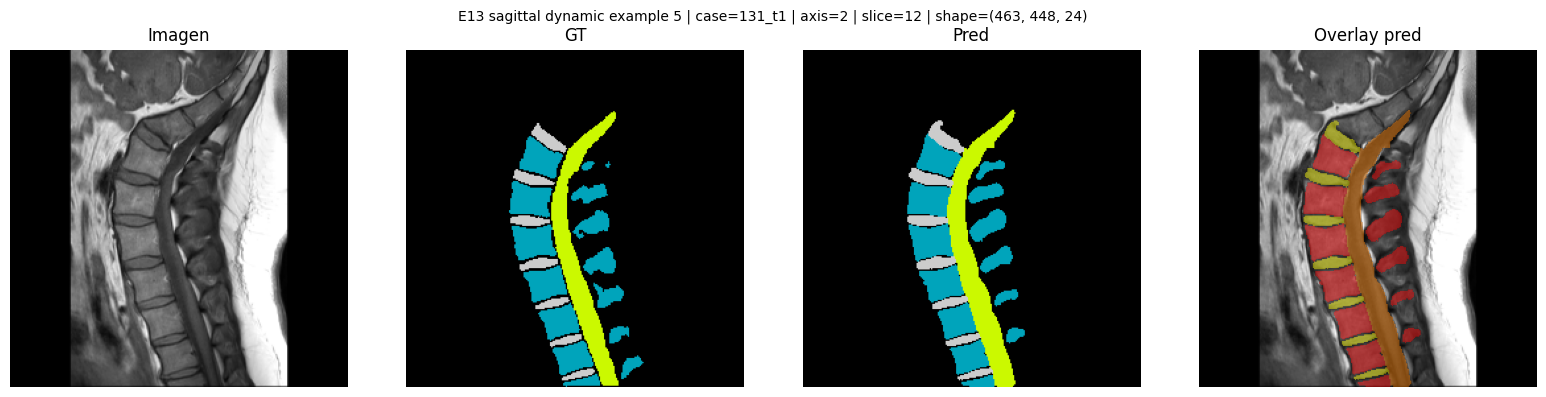

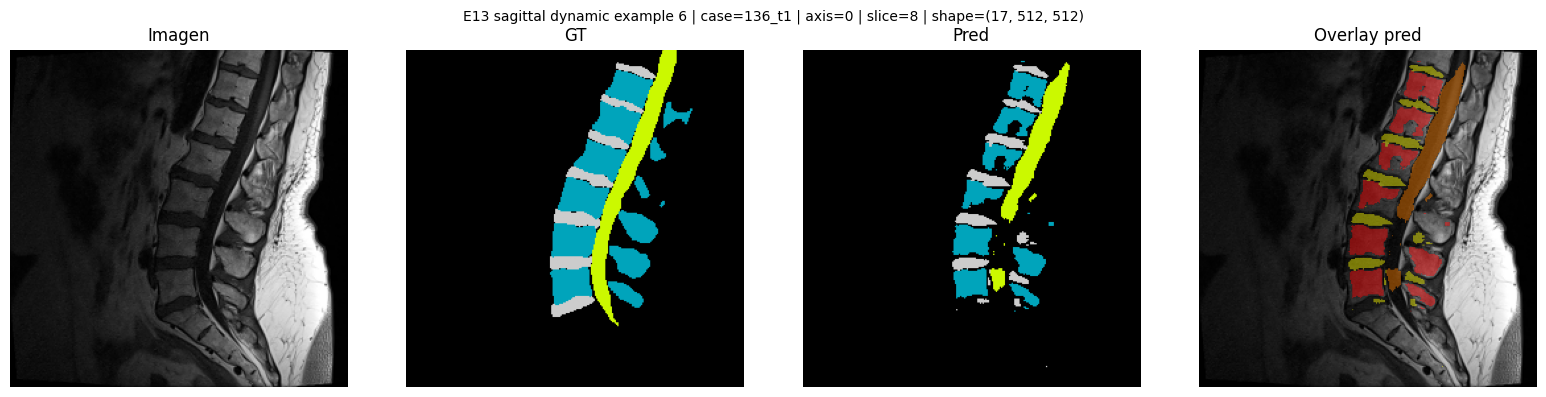

,example_id,plane,case_id,selected_axis,slice_index,selection_score,original_shape_zyx,original_slice_shape,axis_candidates,image_path,mask_path,figure_path,foreground_ratio,n_components,present_classes,flags,mean_confidence,mean_fg_confidence
0,1,sagittal,101_t1,2,8,0.226307,"(298, 320, 17)","(298, 320)","[{""axis"": 0, ""n_slices"": 298, ""slice_2d_shape"": [320, 17], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [298, 17], ""valid_2d"": false}, {""axis"": 2, ""n_slic...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/101_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_01.png,0.181458,13,"[1, 2, 3]",[muchos_componentes],0.907111,0.843732
1,2,sagittal,116_t1,2,5,0.162707,"(320, 320, 15)","(320, 320)","[{""axis"": 0, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 2, ""n_slic...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/116_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/116_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_02.png,0.106369,12,"[1, 2, 3]",[muchos_componentes],0.917606,0.853816
2,3,sagittal,117_t1,2,13,0.163138,"(448, 448, 24)","(448, 448)","[{""axis"": 0, ""n_slices"": 448, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 448, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 2, ""n_slic...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/117_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/117_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_03.png,0.115646,14,"[1, 2, 3]",[muchos_componentes],0.924658,0.857124
3,4,sagittal,12_t1,2,8,0.201606,"(320, 320, 15)","(320, 320)","[{""axis"": 0, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 320, ""slice_2d_shape"": [320, 15], ""valid_2d"": false}, {""axis"": 2, ""n_slic...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/12_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/12_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_04.png,0.152420,11,"[1, 2, 3]",[muchos_componentes],0.922323,0.888282
4,5,sagittal,131_t1,2,12,0.190269,"(463, 448, 24)","(463, 448)","[{""axis"": 0, ""n_slices"": 463, ""slice_2d_shape"": [448, 24], ""valid_2d"": false}, {""axis"": 1, ""n_slices"": 448, ""slice_2d_shape"": [463, 24], ""valid_2d"": false}, {""axis"": 2, ""n_slic...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/131_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/131_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_05.png,0.146667,7,"[1, 2, 3]",[],0.922671,0.861709
5,6,sagittal,136_t1,0,8,0.159492,"(17, 512, 512)","(512, 512)","[{""axis"": 0, ""n_slices"": 17, ""slice_2d_shape"": [512, 512], ""valid_2d"": true}, {""axis"": 1, ""n_slices"": 512, ""slice_2d_shape"": [17, 512], ""valid_2d"": false}, {""axis"": 2, ""n_slice...",/content/drive/MyDrive/PFI_MVP/data/SPIDER/images/images/136_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/masks/masks/136_t1.mha,/content/drive/MyDrive/PFI_MVP/figures/E13_sagittal_dynamic_example_06.png,0.095123,29,"[1, 2, 3]",[muchos_componentes],0.892520,0.734380


,class_id,class_name,dice,iou,pred_pixels,gt_pixels,example_id,plane,case_id,selected_axis,slice_index
0,0,background,0.976744,0.954545,53644,53209,1,sagittal,101_t1,2,8
1,1,vertebra_group,0.903492,0.823972,7306,7957,1,sagittal,101_t1,2,8
2,2,canal,0.902612,0.822509,2988,2793,1,sagittal,101_t1,2,8
3,3,disc_group,0.829606,0.708827,1598,1577,1,sagittal,101_t1,2,8
4,0,background,0.983291,0.967131,58565,59815,2,sagittal,116_t1,2,5
5,1,vertebra_group,0.858989,0.752832,4099,3638,2,sagittal,116_t1,2,5
6,2,canal,0.821157,0.696579,2202,1617,2,sagittal,116_t1,2,5
7,3,disc_group,0.707746,0.547684,670,466,2,sagittal,116_t1,2,5
8,0,background,0.977340,0.955685,57957,58946,3,sagittal,117_t1,2,13
9,1,vertebra_group,0.824257,0.701053,4390,4498,3,sagittal,117_t1,2,13


In [9]:
sag_rows = []
sag_metric_rows = []

if len(sag_cases_df) > 0:
    for i, (_, r) in enumerate(sag_cases_df.head(6).iterrows(), 1):
        img_path = resolve_spider_path(r, "image")
        mask_path = resolve_spider_path(r, "mask")

        if img_path is None:
            print("No se pudo resolver imagen para fila", i)
            continue

        result = infer_sagittal_spider(img_path, mask_path)

        if result["gt"] is not None:
            metrics = dice_by_class(
                result["pred"],
                result["gt"],
                num_classes=sag_num_classes,
                class_names=SAGITTAL_CLASS_NAMES,
            )
            metrics["example_id"] = i
            metrics["plane"] = "sagittal"
            metrics["case_id"] = candidate_case_id_from_row(r)
            metrics["selected_axis"] = result["selected_axis"]
            metrics["slice_index"] = result["slice_index"]
            sag_metric_rows.append(metrics)

        out_path = FIGURES_ROOT / f"E13_sagittal_dynamic_example_{i:02d}.png"
        save_overlay_figure(
            result["image"],
            result["pred"],
            out_path,
            title=(
                f"E13 sagittal dynamic example {i} | "
                f"case={candidate_case_id_from_row(r)} | "
                f"axis={result['selected_axis']} | "
                f"slice={result['slice_index']} | "
                f"shape={result['original_shape_zyx']}"
            ),
            gt=result["gt"],
        )

        sag_rows.append({
            "example_id": i,
            "plane": "sagittal",
            "case_id": candidate_case_id_from_row(r),
            "selected_axis": result["selected_axis"],
            "slice_index": result["slice_index"],
            "selection_score": result["selection_score"],
            "original_shape_zyx": str(result["original_shape_zyx"]),
            "original_slice_shape": str(result["original_slice_shape"]),
            "axis_candidates": json.dumps(result["axis_candidates"], ensure_ascii=False),
            "image_path": str(img_path),
            "mask_path": str(mask_path) if mask_path else None,
            "figure_path": str(out_path),
            **result["quality"],
        })

sag_examples_df = pd.DataFrame(sag_rows)
sag_metrics_df = pd.concat(sag_metric_rows, ignore_index=True) if sag_metric_rows else pd.DataFrame()

sag_examples_df.to_csv(E13_ROOT / "E13_sagittal_examples_quality.csv", index=False)
sag_metrics_df.to_csv(E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv", index=False)

display(sag_examples_df)
display(sag_metrics_df.head(24))


## 6. Reporte final E13

In [10]:
def df_summary(df, name):
    return {
        "name": name,
        "rows": int(len(df)),
        "columns": list(df.columns) if len(df.columns) else [],
    }


report = {
    "notebook": "21_E13_multiplanar_inference_pipeline",
    "goal": "common inference pipeline for sagittal SPIDER and axial T2 models",
    "models": {
        "sagittal_spider": {
            "path": str(SAGITTAL_MODEL_PATH),
            "num_classes": sag_num_classes,
            "target_size": list(sag_target_size),
            "axis_from_checkpoint": sag_axis,
            "slice_strategy": sag_slice_strategy,
            "runtime_axis_strategy": "dynamic_smallest_valid_stack_axis",
        },
        "axial_t2_alkafri": {
            "path": str(AXIAL_MODEL_PATH),
            "num_classes": 6,
            "target_size": [IMG_SIZE, IMG_SIZE],
        },
    },
    "outputs": {
        "axial_quality_csv": str(E13_ROOT / "E13_axial_examples_quality.csv"),
        "axial_metrics_csv": str(E13_ROOT / "E13_axial_examples_metrics_by_class.csv"),
        "sagittal_quality_csv": str(E13_ROOT / "E13_sagittal_examples_quality.csv"),
        "sagittal_metrics_csv": str(E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv"),
    },
    "summaries": [
        df_summary(axial_examples_df, "axial_examples_quality"),
        df_summary(axial_metrics_df, "axial_examples_metrics_by_class"),
        df_summary(sag_examples_df, "sagittal_examples_quality"),
        df_summary(sag_metrics_df, "sagittal_examples_metrics_by_class"),
    ],
    "decision": "common_multiplanar_inference_pipeline_ready_for_agent_prototype",
}

report_path = E13_ROOT / "E13_multiplanar_pipeline_report.json"
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

md = f"""# E13 - Pipeline común de inferencia multiplanar

## Objetivo

Este notebook implementa un pipeline común para ejecutar inferencia con los dos modelos finales del proyecto:

- Modelo sagital SPIDER consolidado en E12.
- Modelo axial T2 Al-Kafri/Sudirman entrenado en E10.

## Resultado

Se generaron funciones comunes para:

- cargar modelos,
- preprocesar imágenes,
- ejecutar inferencia 2D,
- generar máscaras,
- generar overlays,
- calcular métricas por clase cuando existe ground truth,
- calcular quality flags.

## Corrección sagital integrada

La inferencia sagital usa detección dinámica del eje de stack por caso. Esto evita asumir `axis=2` fijo, que funciona para volúmenes tipo `(298, 320, 17)` pero falla en casos tipo `(17, 512, 512)`. La regla prioriza el eje con menor cantidad de slices siempre que el corte 2D tenga dimensiones válidas.

## Modelos usados

- Sagital: `{SAGITTAL_MODEL_PATH}`
- Axial T2: `{AXIAL_MODEL_PATH}`

## Salidas

- `{E13_ROOT / "E13_axial_examples_quality.csv"}`
- `{E13_ROOT / "E13_axial_examples_metrics_by_class.csv"}`
- `{E13_ROOT / "E13_sagittal_examples_quality.csv"}`
- `{E13_ROOT / "E13_sagittal_examples_metrics_by_class.csv"}`

## Decisión

El pipeline común queda listo para avanzar a E14, donde se implementará el prototipo de agente/orquestador IA.
"""

md_path = DOCS_ROOT / "E13_multiplanar_inference_pipeline_conclusion.md"
md_path.write_text(md, encoding="utf-8")

print("Reporte JSON:", report_path)
print("Reporte Markdown:", md_path)
print(json.dumps(report, indent=2, ensure_ascii=False))


Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E13_multiplanar_inference_pipeline/E13_multiplanar_pipeline_report.json
Reporte Markdown: /content/drive/MyDrive/PFI_MVP/docs/E13_multiplanar_inference_pipeline_conclusion.md
{
  "notebook": "21_E13_multiplanar_inference_pipeline",
  "goal": "common inference pipeline for sagittal SPIDER and axial T2 models",
  "models": {
    "sagittal_spider": {
      "path": "/content/drive/MyDrive/PFI_MVP/models/E12_sagittal_multiclass_final_best.pt",
      "num_classes": 4,
      "target_size": [
        256,
        256
      ],
      "axis_from_checkpoint": 2,
      "slice_strategy": "center_window_best_prediction",
      "runtime_axis_strategy": "dynamic_smallest_valid_stack_axis"
    },
    "axial_t2_alkafri": {
      "path": "/content/drive/MyDrive/PFI_MVP/models/E10_axial_t2_final_training_clean_best.pt",
      "num_classes": 6,
      "target_size": [
        256,
        256
      ]
    }
  },
  "outputs": {
    "axial_quality_csv": "/con